In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


In [46]:
df = pd.read_csv('Titanic.csv')
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## EDA

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


In [48]:
# Unnamed column has the same values for row count so we can drop it
df= df.drop(columns =['Unnamed: 0'])

In [49]:
# Finding the statistical information from the data
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [32]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [33]:
df['survived'] = df['survived'].map({0:'Died', 1:'Survived'})
df['survived']

0          Died
1      Survived
2      Survived
3      Survived
4          Died
         ...   
886        Died
887    Survived
888        Died
889    Survived
890        Died
Name: survived, Length: 891, dtype: object

In [34]:
# Seperate the nominal and odinal colums and process the nominal to the loop

Nominal = df.select_dtypes(exclude='object').columns
odinal = df.select_dtypes(include='object').columns

for i in df.columns:
    print(f'The {i} have - {round(df[i].isnull().mean()*100,2)}% missing values')

The survived have - 0.0% missing values
The pclass have - 0.0% missing values
The sex have - 0.0% missing values
The age have - 19.87% missing values
The sibsp have - 0.0% missing values
The parch have - 0.0% missing values
The fare have - 0.0% missing values
The embarked have - 0.22% missing values
The class have - 0.0% missing values
The who have - 0.0% missing values
The adult_male have - 0.0% missing values
The deck have - 77.22% missing values
The embark_town have - 0.22% missing values
The alive have - 0.0% missing values
The alone have - 0.0% missing values


# Plot the data to evaluate Imputation
   - Age 
   - embarked     
   - deck
   - embark_town  

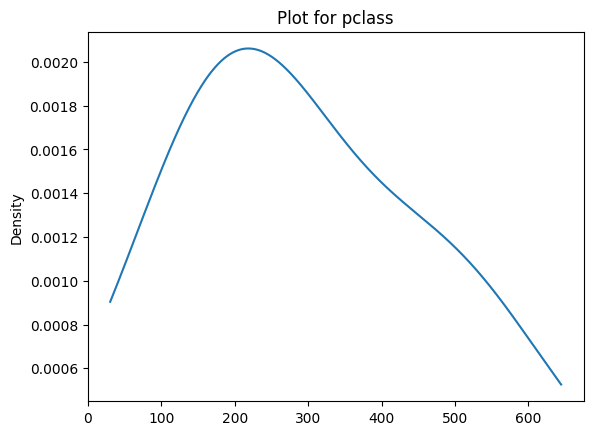

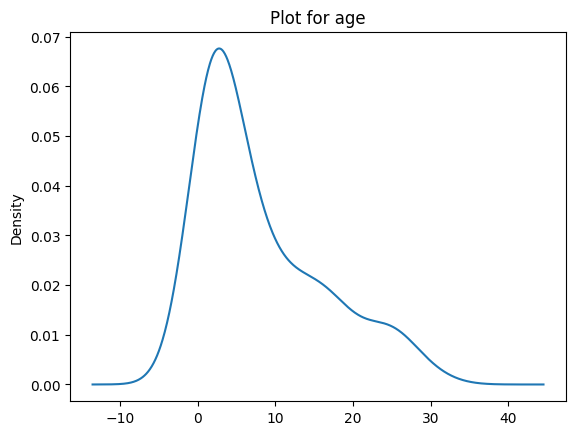

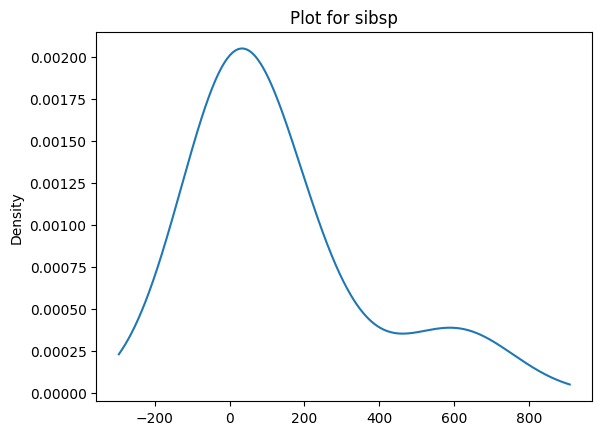

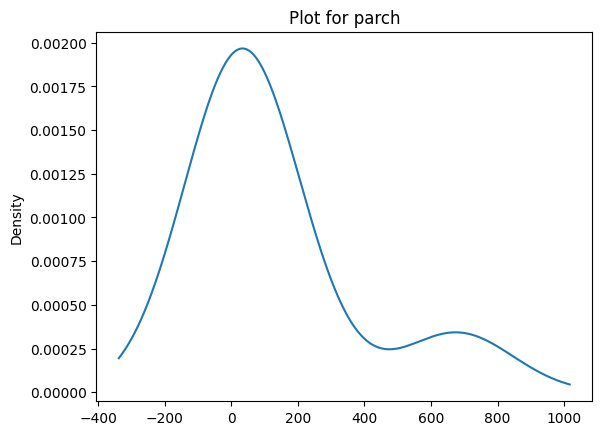

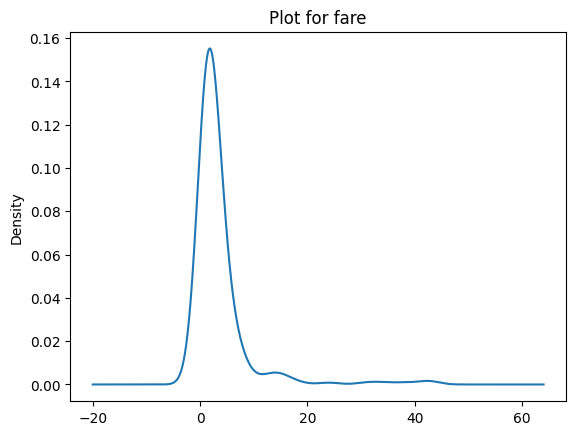

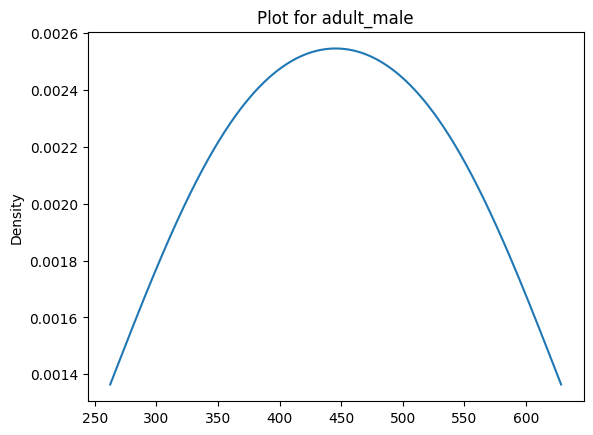

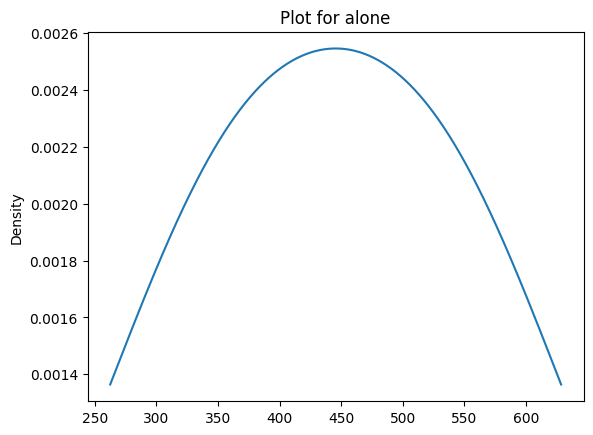

In [35]:
for i in Nominal:
    plt.title(f'Plot for {i}')
    df[i].value_counts().plot(kind='kde')
    plt.show()

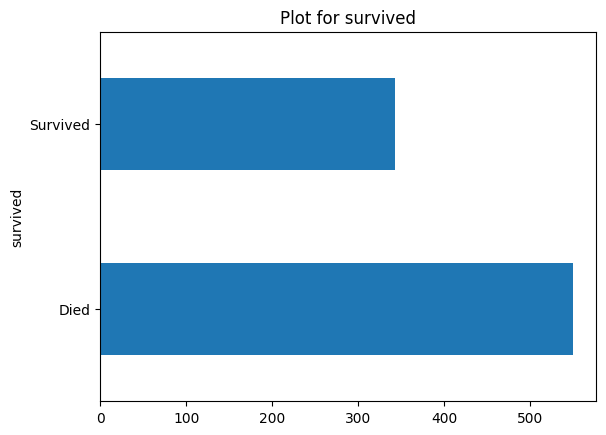

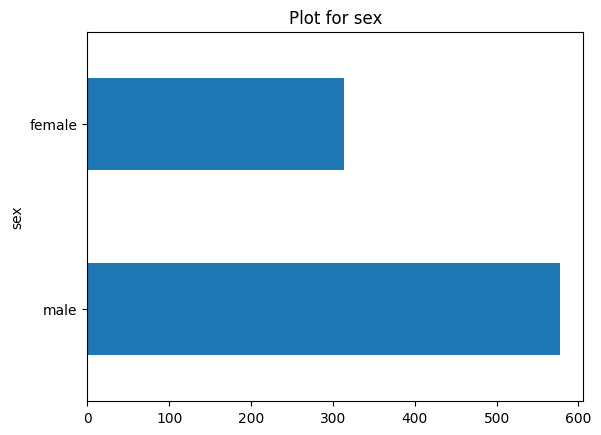

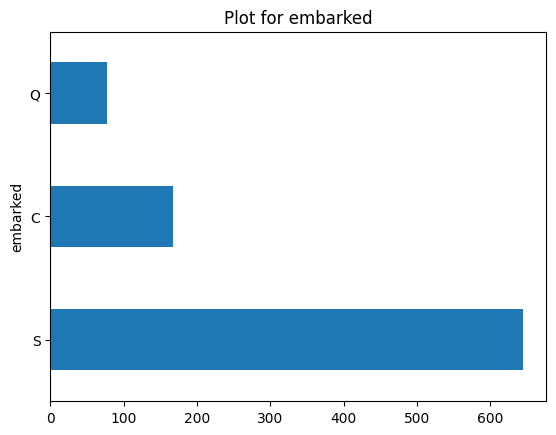

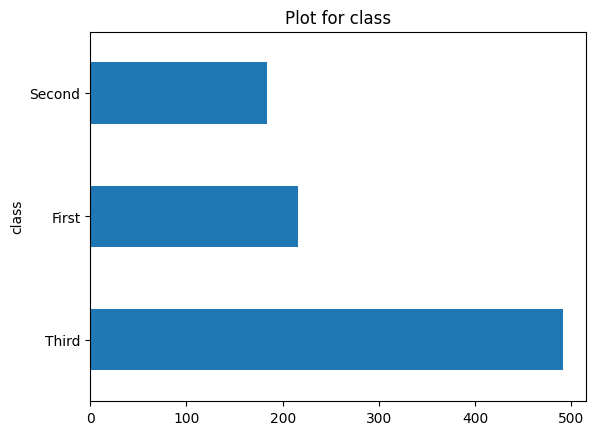

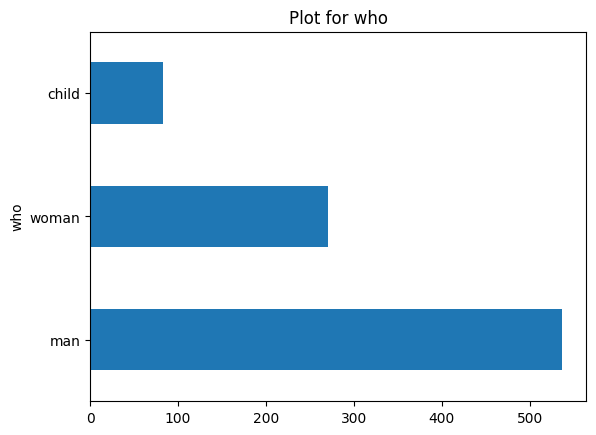

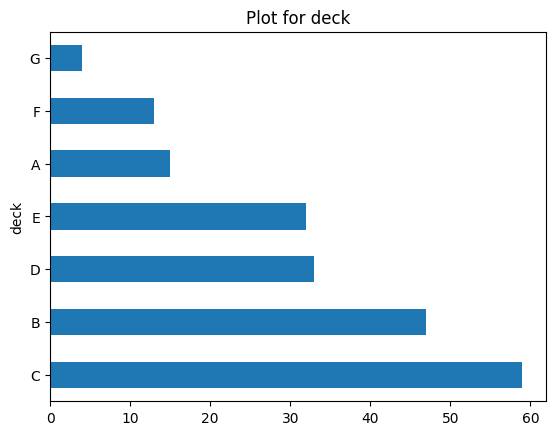

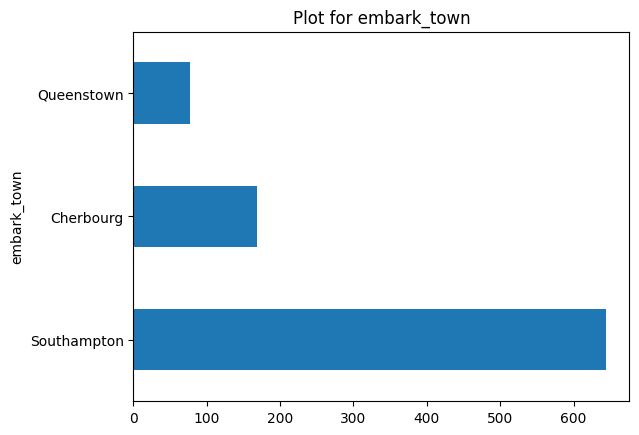

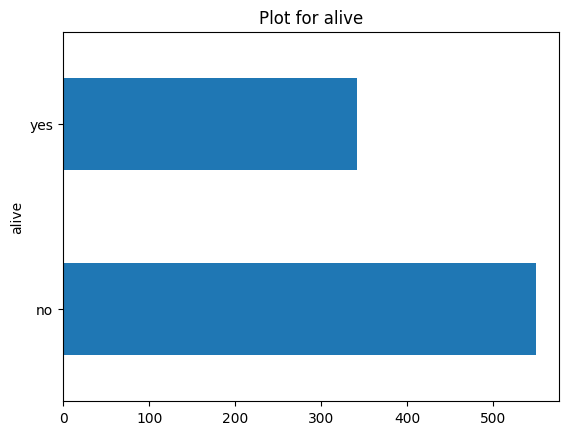

In [36]:
for i in odinal:
    plt.title(f'Plot for {i}')
    df[i].value_counts().plot(kind='barh')
    plt.show()

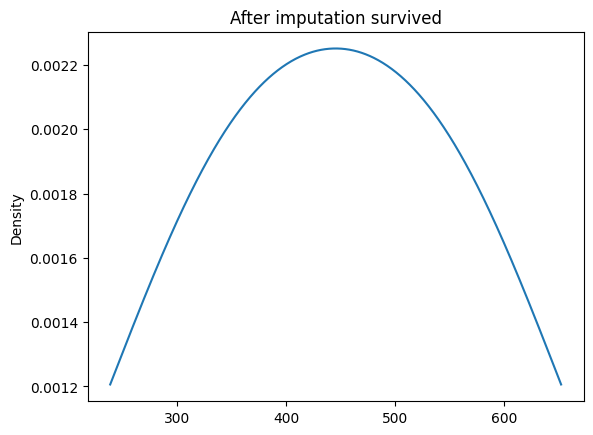

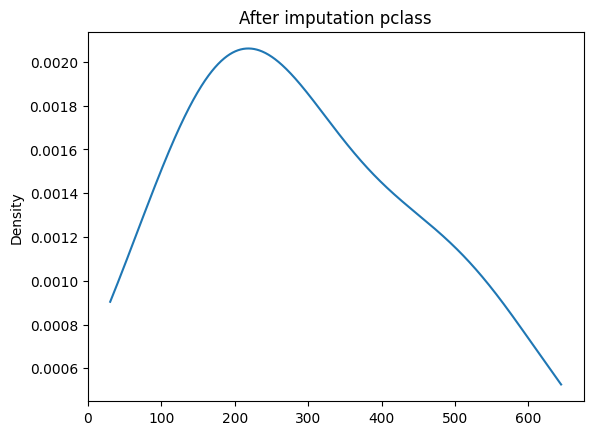

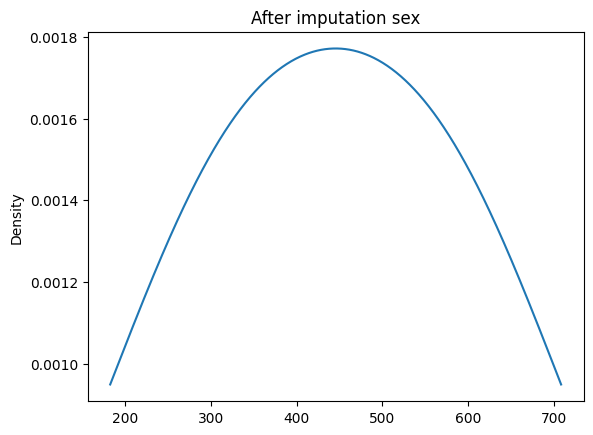

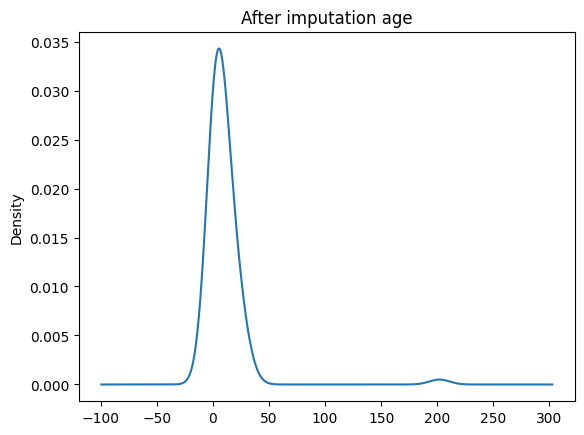

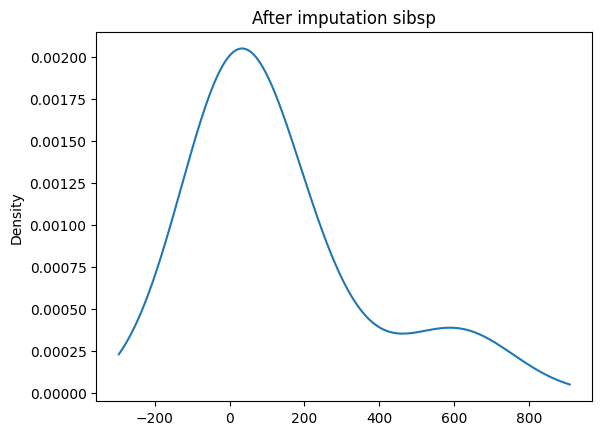

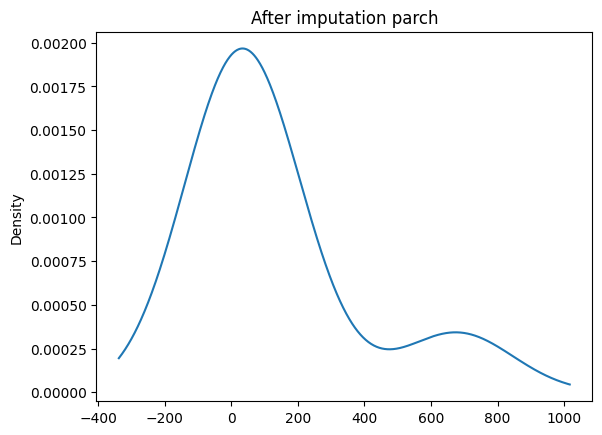

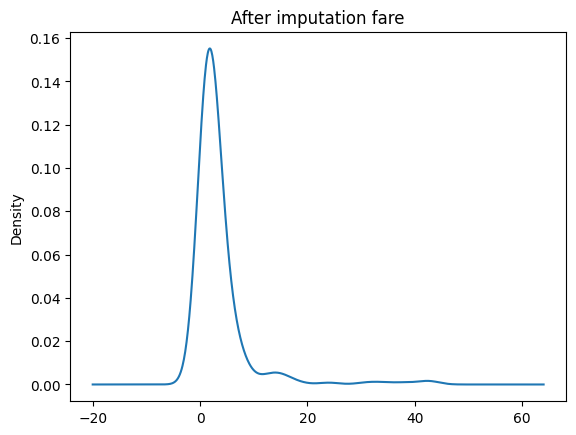

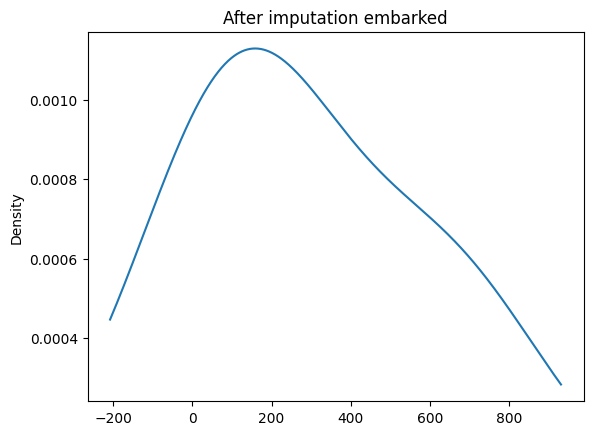

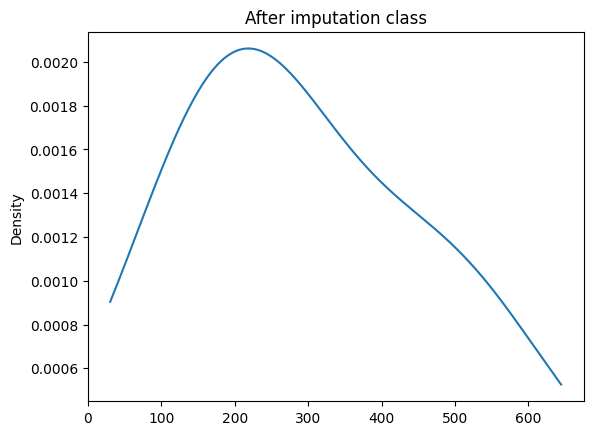

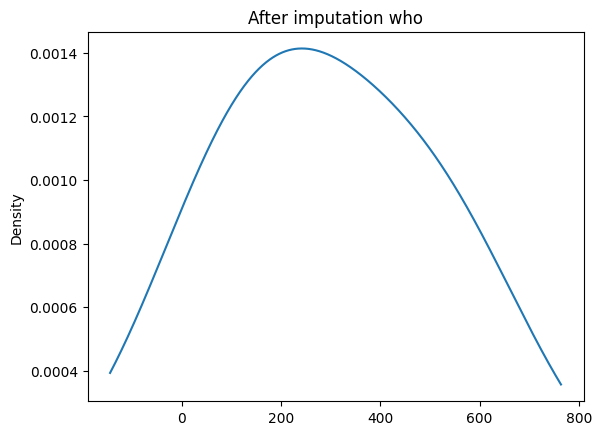

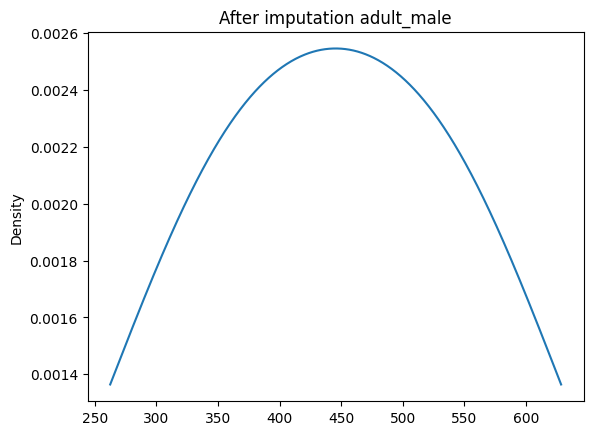

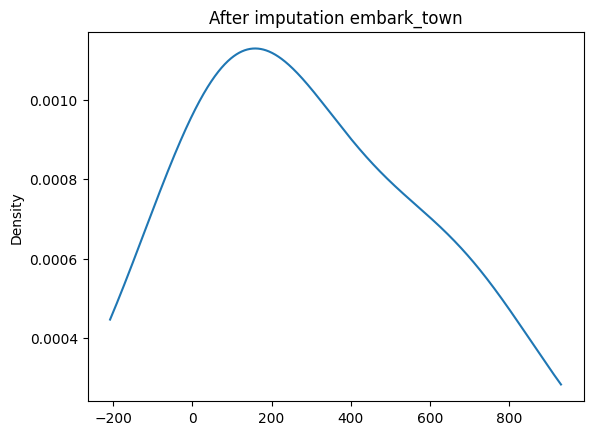

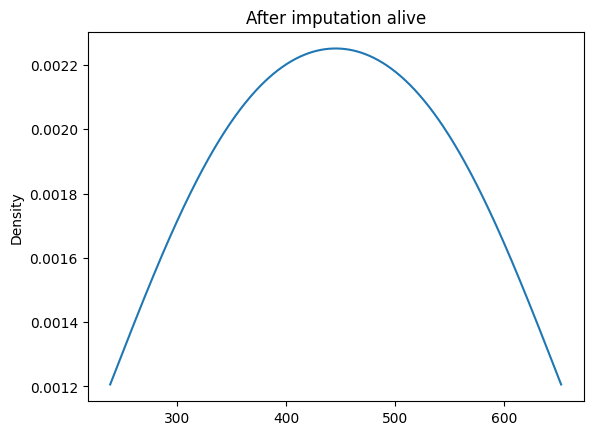

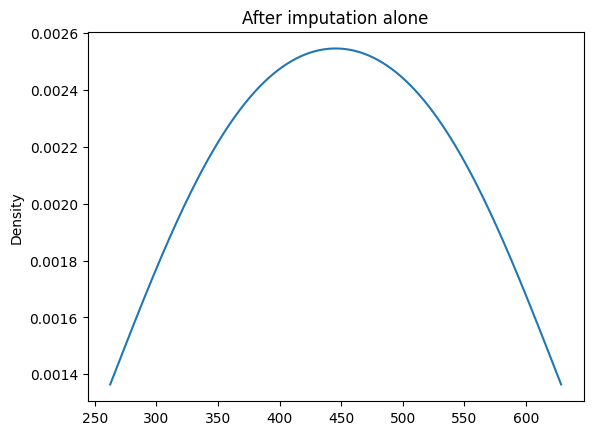

In [37]:
## Find the columns for the missing value and take necessary steps:


for i in Nominal:
    if round((df[i].isna().mean())*100,2) != 0:
        if round((df[i].isna().mean())*100,2) < 50:
            df[i] = df[i].fillna(df[i].median())
        elif round((df[i].isna().mean())*100,2) > 50:
            df.drop(columns=[i],inplace=True)

for i in odinal:
    if round((df[i].isna().mean())*100,2) != 0:
        if round((df[i].isna().mean())*100,2) < 50:
            df[i] = df[i].fillna(df[i].mode()[0])
        elif round((df[i].isna().mean())*100,2) > 50:
            df.drop(columns=[i],inplace=True)

for i in df.columns:
    plt.title(f'After imputation {i}')
    df[i].value_counts().plot(kind='kde')
    plt.show()    

